# Student Identification & Submission Details

Please complete the following information before submitting your notebook.

**UNI:**  xs2591, jz4007, awt2135   
**Full Name:**  Xiangxinrui Shan, Jimiao Zhang, Aoife Turner   
**Public GitHub Repository URL (Final Project Report & Code):** https://github.com/aoifeturner/Project-1-QMSS

---

# World Happiness Classification Competition

## Project Objectives

This competition is designed to help you:

- Develop a deep understanding of how machine learning models function
- Understand the role and impact of model hyperparameters
- Learn from systematic experimentation and model iteration
- Produce a professional, well-structured notebook report
- Publish the final project as a portfolio-ready GitHub repository

---

## Project Workflow

You will complete the project through the following stages:

1. **Load and Merge Datasets**  
   - Import all relevant datasets  
   - Perform necessary joins and validation  

2. **Data Preprocessing**  
   - Build preprocessing pipelines using `sklearn`'s `ColumnTransformer`  
   - Handle missing values, encoding, scaling, and feature engineering  

3. **Model Training**  
   - Fit the model using the processed data  
   - Save both the preprocessing pipeline and trained model  

4. **Prediction and Evaluation**  
   - Generate predictions  
   - Evaluate performance using appropriate metrics  

5. **Hyperparameter Tuning**  
   - Systematically tune model parameters  
   - Compare performance across configurations  

6. **Deep Learning Experimentation**  
   - Implement and evaluate a neural network approach  
   - Compare results with classical ML models  

7. **Model Explainability (SHAP)**  
   - Apply SHAP for feature importance analysis  
   - Interpret and explain model decisions  

8. **Final Report Submission**  
   - Clean and organize the notebook  
   - Ensure full reproducibility  
   - Upload the final report and code to a public GitHub repository  

---

## 0. Loading Datasets

In this section, we load the **World Happiness 2023** datasets that will be used throughout the project.

**Objectives of this stage:**

- Import the datasets into the notebook environment
- Inspect their structure and contents
- Verify column names and data types
- Identify potential inconsistencies before merging

> Careful dataset inspection at this stage prevents downstream errors and ensures a clean modeling pipeline.

### Replication Requirements
Place the two CSV files (WHR_2023.csv and newcountryvars.csv) in the data folder. The project outline should minimally look like:

-Project.ipynb

-data

    -> WHR_2023.csv

    -> newcountryvars.csv

Please reference the README.md on Github & the requirements.txt.

In [1]:
import os

base = "data"
print("Exists WHR_2023.csv:", os.path.exists("data/WHR_2023.csv"))
print("Exists newcountryvars.csv:", os.path.exists("data/newcountryvars.csv"))

Exists WHR_2023.csv: True
Exists newcountryvars.csv: True


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
whr_df = pd.read_csv(f"{base}/WHR_2023.csv")

# Inspect the first few rows to understand the structure
whr_df.head()


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394


In [3]:
# Convert the regression target ('happiness_score') into classification labels
# We'll use quartiles to create 4 happiness categories: Very Low, Low, High, Very High

# Define quartiles
whr_df['happiness_category'] = pd.qcut(whr_df['happiness_score'],
                                       q=5,
                                       labels=['Very Low', 'Low','Average', 'High', 'Very High'])

# Select features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert y_train and y_test to numerical labels
y_train_labels = y_train.astype('category').cat.codes
y_test_labels = y_test.astype('category').cat.codes

### Conceptual Question

In the next cell, briefly explain the following:

1. What does `y_train.astype('category').cat.codes` do?
2. What is the difference between `y_train_labels` and `y_train`?

Keep your explanation clear and concise.

1. y_train.astype('category').cat.codes converts the categorical labels in y_train into numerical integer codes. First, the values are cast to a pandas categorical data type, and then each category is mapped to a unique integer (e.g., 0, 1, 2, 3, 4). This transformation is necessary because numerical inputs are easier to use later rather than string labels.
2. y_train contains the original categorical labels (e.g., "Very Low", "Low", "Average", "High", "Very High"), which are easier for us to read. In contrast, y_train_labels contains the corresponding numerical codes that represent those categories. The numerical representation is used for training and evaluating machine learning models, while the original labels are useful for interpretation and visualization.

### Add New Data

In [4]:
# Truncated and cleaned up region data to merge
countrydata = pd.read_csv(f"{base}/newcountryvars.csv")

countrydata.head()

,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,India,1339180127,21.9,0.623559,68.322,11.696590,6.298834,5663.474799
1,Nigeria,190886311,70.0,0.527105,53.057,9.970482,6.000000,5442.901264
2,Mexico,129163276,46.2,0.761683,76.972,13.299090,8.554985,16383.106680
3,Pakistan,197015955,29.5,0.550354,66.365,8.106910,5.089460,5031.173074
4,Bangladesh,164669751,31.5,0.578824,71.985,10.178706,5.241577,3341.490722


In [5]:
whr_countries = set(whr_df["country"].dropna().unique())
countrydata_countries = set(countrydata["country_name"].dropna().unique())

common_countries = whr_countries.intersection(countrydata_countries)
only_in_whr = whr_countries - countrydata_countries
only_in_countrydata = countrydata_countries - whr_countries

print("Number of countries in whr_df:", len(whr_countries))
print("Number of countries in countrydata:", len(countrydata_countries))
print("Number of common countries:", len(common_countries))

print("\nExamples only in whr_df:", list(sorted(only_in_whr))[:10])
print("Examples only in countrydata:", list(sorted(only_in_countrydata))[:10])

Number of countries in whr_df: 137
Number of countries in countrydata: 174
Number of common countries: 128

Examples only in whr_df: ['Congo (Brazzaville)', 'Congo (Kinshasa)', 'Czechia', 'Hong Kong S.A.R. of China', 'North Macedonia', 'State of Palestine', 'Taiwan Province of China', 'Turkiye', 'Vietnam']
Examples only in countrydata: ['Angola', 'Azerbaijan', 'Belarus', 'Belize', 'Bhutan', 'Brunei', 'Burundi', 'Central African Republic', 'Congo', 'Cuba']


Because the main objective of the analysis is to model happiness scores, I used a left join, keeping all observations from whr_df and appending socioeconomic indicators from countrydata where a match exists.

In [6]:
# Merge in new data to X_train and X_test by taking "country" from first table and "country_name" from 2nd table.
# Also check which countries are common in both the datasets, and which type of merge will you perform for the best results.
# Hint: Look on the 'how' parameter of megre function of pandas.

X_train = X_train.merge(
    countrydata,
    left_on="country",
    right_on="country_name",
    how="left"
)

X_test = X_test.merge(
    countrydata,
    left_on="country",
    right_on="country_name",
    how="left"
)

In [7]:
X_train.head(1)

,country,region,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,Madagascar,Sub-Saharan Africa,0.632,0.779,0.178,0.187,0.177,0.134,Madagascar,25570895.0,70.7,0.512149,65.515,10.34614,6.145955,1319.699397


---

## 1. Exploratory Data Analysis and Visualization (EDAV)

In [8]:
print(X_train.dtypes)

country                              str
region                               str
gdp_per_capita                   float64
social_support                   float64
healthy_life_expectancy          float64
freedom_to_make_life_choices     float64
generosity                       float64
perceptions_of_corruption        float64
country_name                         str
population                       float64
population_below_poverty_line    float64
hdi                              float64
life_expectancy                  float64
expected_years_of_schooling      float64
mean_years_of_schooling          float64
gni                              float64
dtype: object


The merged dataset contains a mix of categorical and numerical variables. The categorical variables include country, region, and country_name (all stored as object), while the remaining columns are numeric indicators such as gdp_per_capita, social_support, and additional variables from the second dataset (like population, hdi, life_expectancy). For example, variables like healthy_life_expectancy, generosity, and perceptions_of_corruption are stored as float64 values, indicating that they represent continuous numerical measurements that can be directly used in model training.

After the merge, country_name appears to duplicate the information in country. Both columns are stored as object types, which confirms that they contain string-based identifiers rather than numeric features. Since most machine learning models require numeric inputs, the categorical columns will need to be encoded or removed, and missing values should be handled before model training. Other variables such as population, population_below_poverty_line, gni, and expected_years_of_schooling also appear as float64, suggesting that the dataset includes multiple socioeconomic indicators that may help explain differences in happiness outcomes.

### Missing Values Analysis

In [9]:
missing = X_train.isnull().sum()
percent = (missing / len(X_train)) * 100
pd.DataFrame({
    "Missing Count": missing,
    "Missing %": percent
})

,Missing Count,Missing %
country,0,0.000000
region,0,0.000000
gdp_per_capita,0,0.000000
social_support,0,0.000000
healthy_life_expectancy,0,0.000000
freedom_to_make_life_choices,0,0.000000
generosity,0,0.000000
perceptions_of_corruption,0,0.000000
country_name,6,6.315789
population,6,6.315789


Most variables contain relatively low levels of missingness. However, several variables introduced through the merge contain moderate missing values. For example, `population_below_poverty_line` has the largest missing proportion at approximately **16.8%**, while variables such as `life_expectancy` and `gni` have smaller missing portions of around **7%**.

Although the missingness is noticeable, it remains manageable and can be handled during preprocessing using imputation rather than removing observations.

### Distribution of Key Numerical Features

Select relevant numerical features and plot their histograms. Choose features that may influence the target variable, and briefly comment on notable patterns, skewness, or outliers.

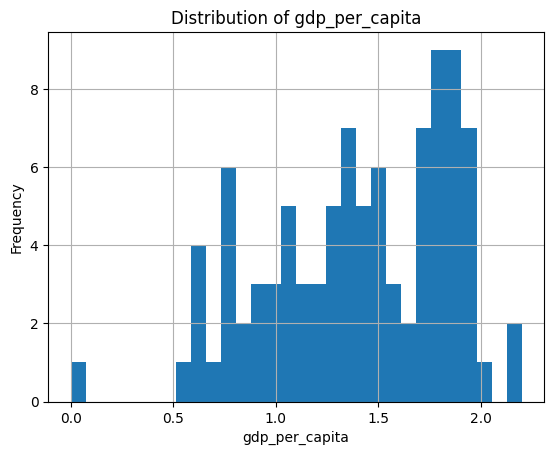

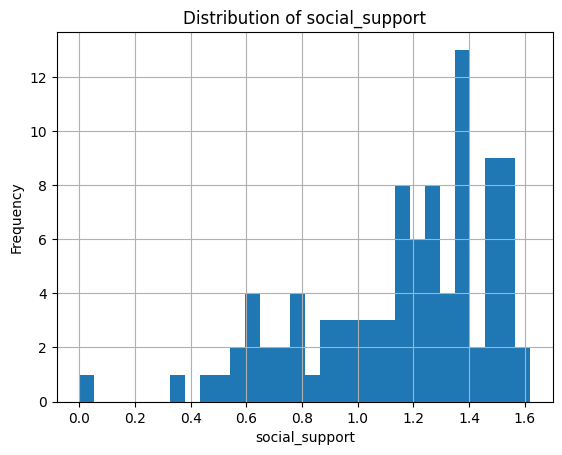

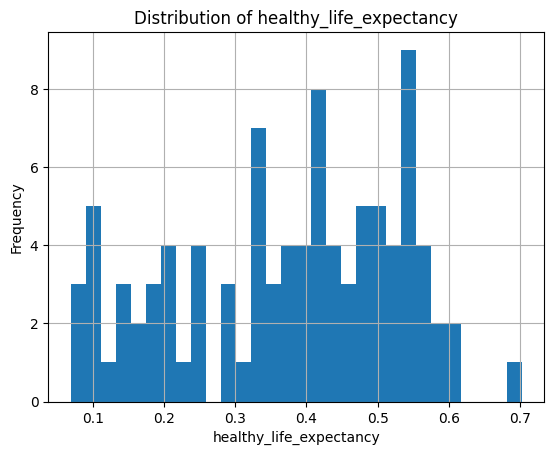

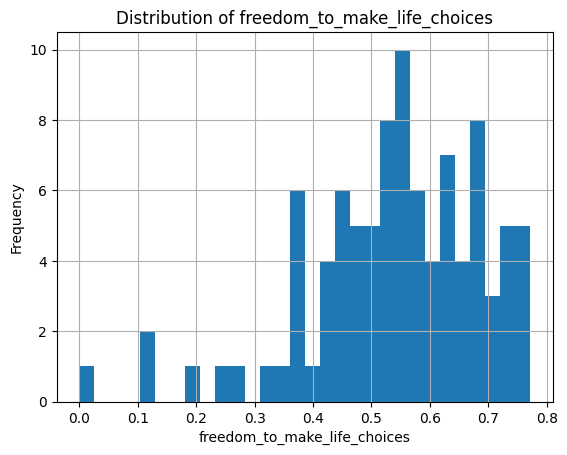

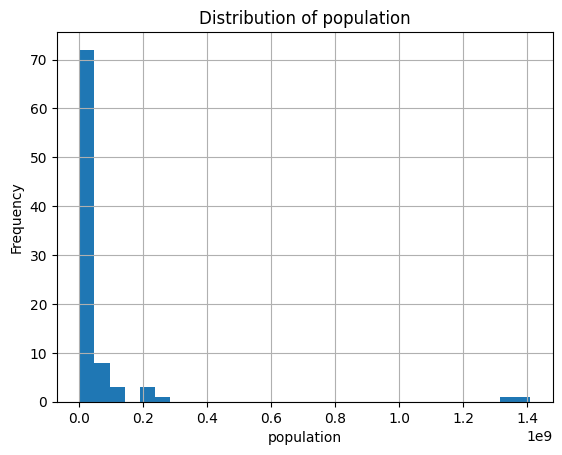

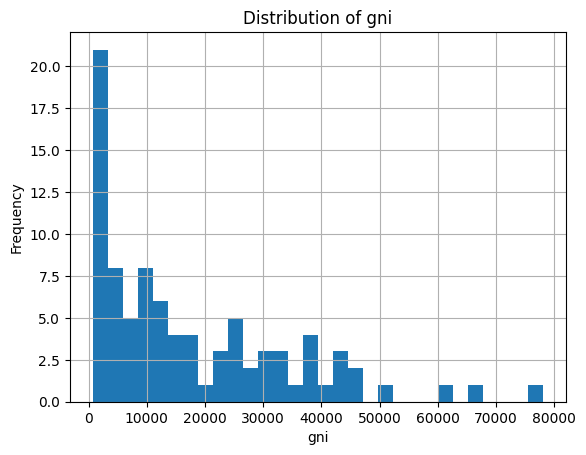

In [10]:
import matplotlib.pyplot as plt

numeric_cols = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_make_life_choices",
    "population",
    "gni"
]

for col in numeric_cols:
    plt.figure()
    X_train[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


Variables such as gdp_per_capita, social_support, healthy_life_expectancy, and freedom_to_make_life_choices appear to have relatively concentrated distributions. Most countries fall within a moderate range of these indicators, although there are a few countries with lower values. These distributions appear moderately skewed but not extremely irregular.

In contrast, population shows a very strong right-skewed distribution. Most countries have relatively small populations, while a few countries have extremely large populations, which creates a long right tail. This pattern is common in global population data. Similarly, gni also shows a right-skewed distribution. A small number of countries have very high gross national income values compared to the majority of countries.

These skewed distributions suggest that applying transformations such as logarithmic scaling may help reduce the influence of extreme values and improve model stability during training.

### Distribution of Categorical Variables

Plot the distribution of relevant categorical variables using appropriate visualizations (e.g., count plots or bar charts). Briefly comment on class imbalance or notable patterns.

Categorical cols: ['country', 'region', 'country_name']


C:\Users\AoifeTurner\AppData\Local\Temp\ipykernel_30620\915095482.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


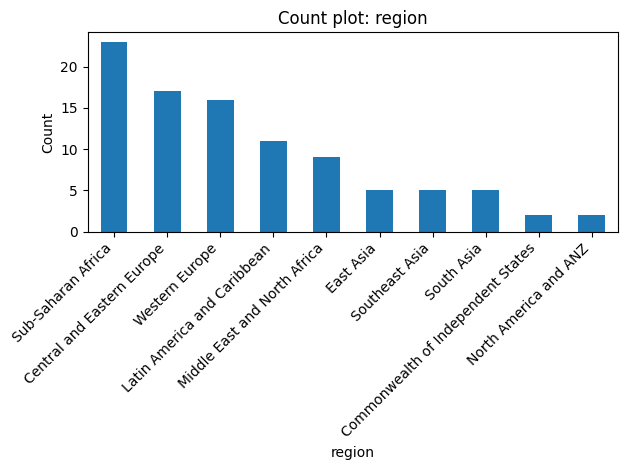

In [11]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical cols:", cat_cols)

for col in ["region"]:
    if col in X_train.columns:
        plt.figure()
        X_train[col].value_counts(dropna=False).plot(kind="bar")
        plt.title(f"Count plot: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

The count plot shows the distribution of countries across different regions. The dataset is not evenly distributed across regions. Sub-Saharan Africa contains the largest number of countries with over 20, followed by Central and Eastern Europe and Western Europe (16-17). Some regions, such as North America and ANZ and Commonwealth of Independent States, have very few observations, totaling less than 5. This indicates that the dataset is imbalanced across regions. This imbalance may influence model learning, as regions with more observations may have a stronger influence on the training process.

### Feature Correlation Analysis

Analyze the relationships between numerical features using correlation coefficients. Compute and visualize:

- **Pearson correlation** — linear relationships
- **Spearman correlation** — monotonic relationships
- **Kendall correlation** — rank-based relationships

Use correlation matrices and heatmaps where appropriate. Briefly interpret strong positive or negative correlations and discuss potential multicollinearity.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

num_df = X_train.select_dtypes(include=["int64", "float64"]).copy()
num_df.shape, num_df.columns

((95, 13),
 Index(['gdp_per_capita', 'social_support', 'healthy_life_expectancy',
        'freedom_to_make_life_choices', 'generosity',
        'perceptions_of_corruption', 'population',
        'population_below_poverty_line', 'hdi', 'life_expectancy',
        'expected_years_of_schooling', 'mean_years_of_schooling', 'gni'],
       dtype='str'))

In [13]:
corr_pearson = num_df.corr(method="pearson")
corr_spearman = num_df.corr(method="spearman")
corr_kendall = num_df.corr(method="kendall")

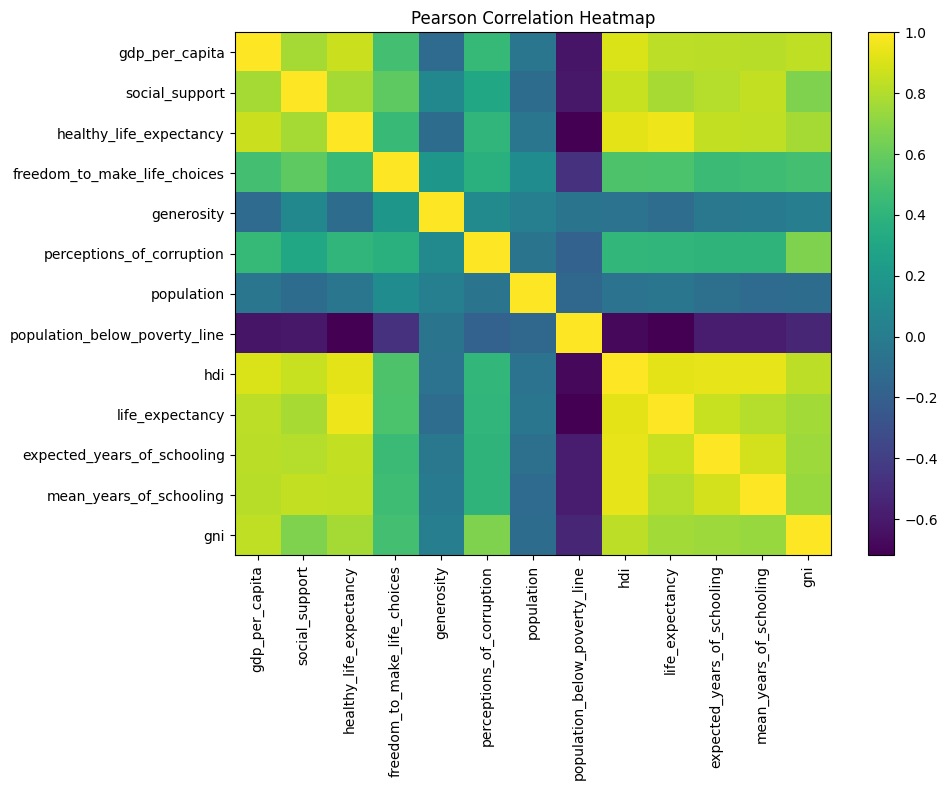

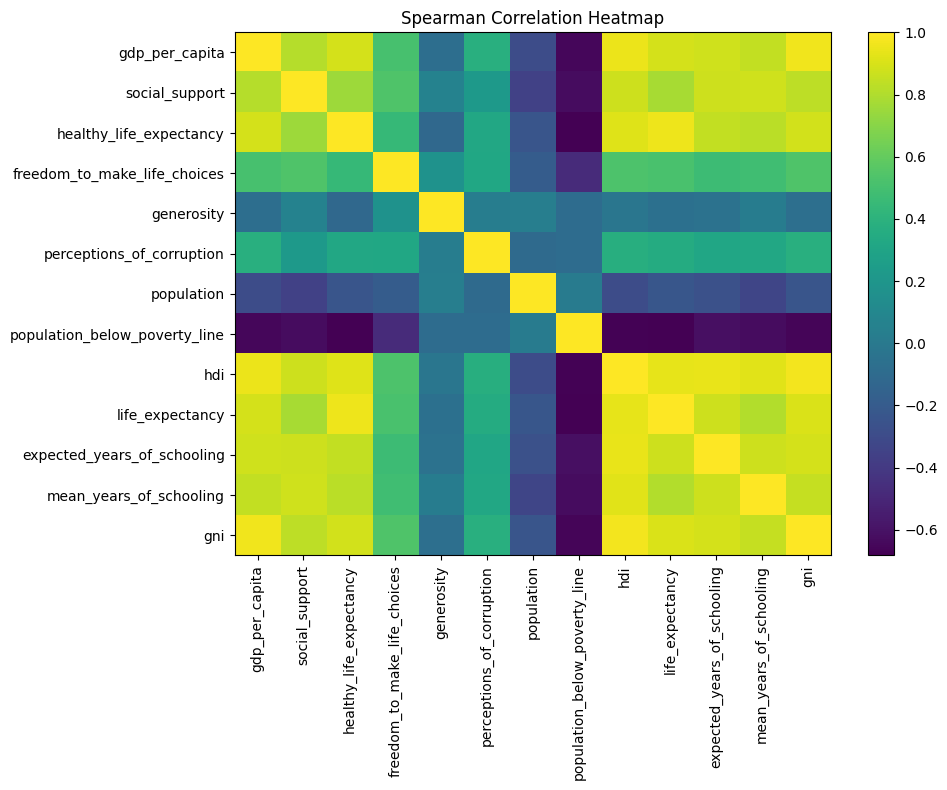

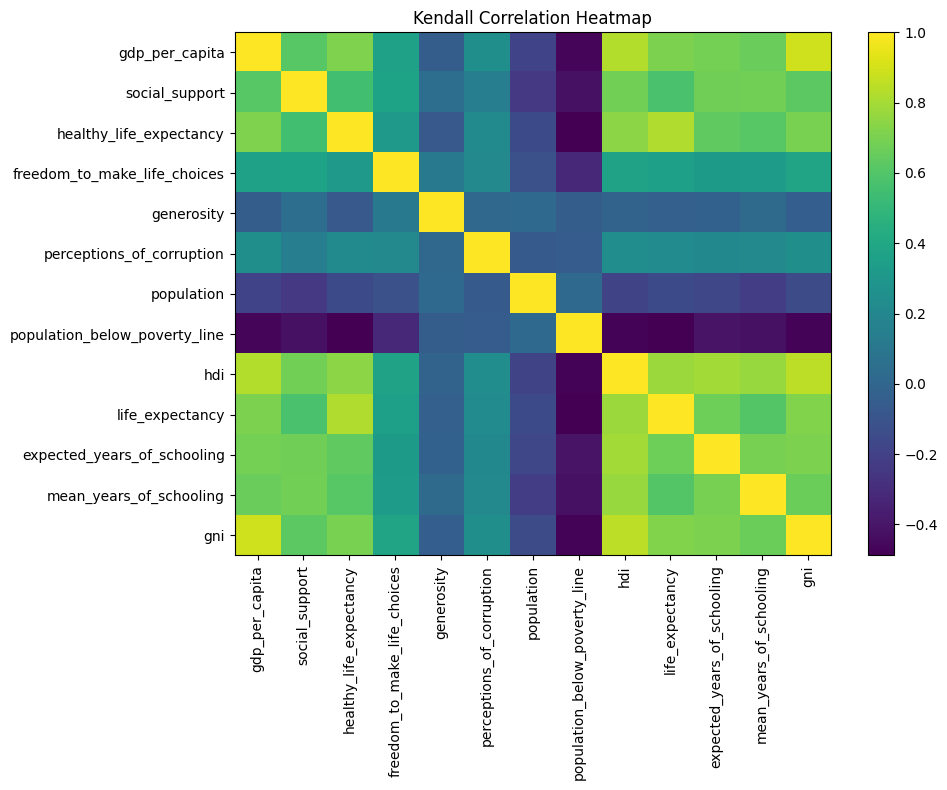

In [14]:
def plot_corr_heatmap(corr, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.title(title)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(corr_pearson, "Pearson Correlation Heatmap")
plot_corr_heatmap(corr_spearman, "Spearman Correlation Heatmap")
plot_corr_heatmap(corr_kendall, "Kendall Correlation Heatmap")

Across all three correlation matrices, several strong positive relationships can be observed among socioeconomic development indicators. For example, HDI, life expectancy, expected years of schooling, mean years of schooling, and GNI show strong positive correlations with each other. This is expected because these variables all reflect aspects of economic development and human well-being.

Similarly, gdp_per_capita also shows strong positive correlations with variables such as HDI and life expectancy, suggesting that countries with higher economic output per person tend to have better health and education outcomes.

In contrast, population_below_poverty_line shows a strong negative correlation with several development indicators such as HDI, life expectancy, and education variables. This indicates that countries with higher poverty levels tend to have lower development outcomes.

Variables such as generosity and population show relatively weak correlations with most other variables, suggesting that they may capture different aspects of societal conditions.

Although some predictors are strongly correlated, this does not necessarily harm predictive performance for tree-based models such as Random Forest. However, high correlations may indicate multicollinearity, which can make interpretation of feature importance more difficult.

Above all, it is important to note that because the target variable is encoded as categorical bins, correlation signs should be interpreted cautiously.

### Bivariate Analysis and Relationship Exploration

Explore relationships between features and examine how they associate with the target variable. Include:

- Bivariate plots (e.g., scatter plots, box plots, grouped bar charts)
- Correlation tables
- Comparisons of feature distributions across target classes

Briefly summarize key relationships and any patterns that may influence model performance.

<Figure size 800x500 with 0 Axes>

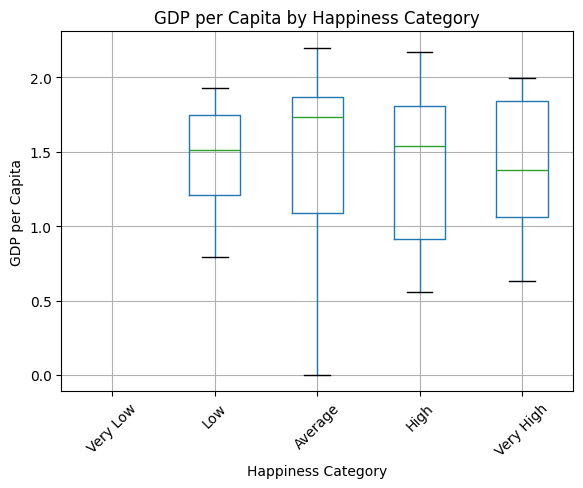

In [15]:
temp = X_train.copy()
temp["happiness_category"] = y_train

plt.figure(figsize=(8,5))
temp.boxplot(column="gdp_per_capita", by="happiness_category", rot=45)
plt.title("GDP per Capita by Happiness Category")
plt.suptitle("")
plt.xlabel("Happiness Category")
plt.ylabel("GDP per Capita")
plt.show()

The boxplot illustrates the relationship between GDP per capita and happiness category. Overall, there appears to be a moderate positive association between GDP per capita and happiness levels.

Countries in lower happiness categories tend to have lower GDP per capita values, with a median around **1.5** in the Low category. In contrast, higher happiness categories show slightly higher median values, reaching approximately **1.6-1.7** in the Average and higher groups.

However, the distributions overlap substantially across categories, indicating that GDP per capita alone does not fully explain differences in happiness levels. The Average happiness category also shows the largest spread, with GDP per capita values ranging roughly from **0 to about 2.2**, suggesting greater economic diversity among countries in this group.

Overall, GDP per capita appears to contribute to higher happiness levels, but it is not sufficient on its own to clearly distinguish between happiness categories.

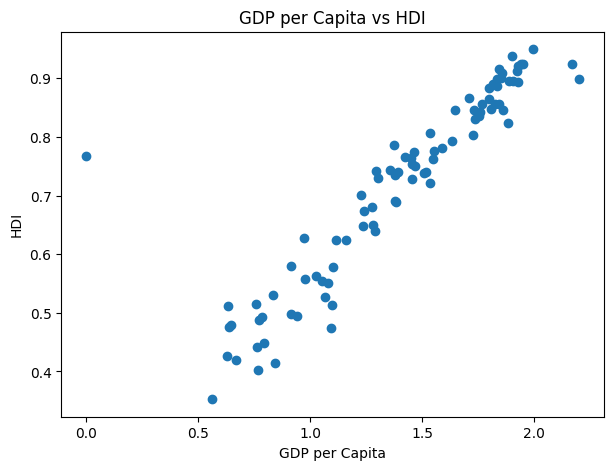

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(X_train["gdp_per_capita"], X_train["hdi"])
plt.xlabel("GDP per Capita")
plt.ylabel("HDI")
plt.title("GDP per Capita vs HDI")
plt.show()

The scatter plot illustrates the relationship between GDP per capita and HDI. Overall, there appears to be a strong positive relationship between the two variables.

Countries with lower GDP per capita generally have lower HDI values, while countries with higher GDP per capita tend to have higher levels of human development. As GDP per capita increases, HDI values also increase.

However, there are a few minor deviations, suggesting that factors other than GDP may also influence HDI.

<Figure size 800x500 with 0 Axes>

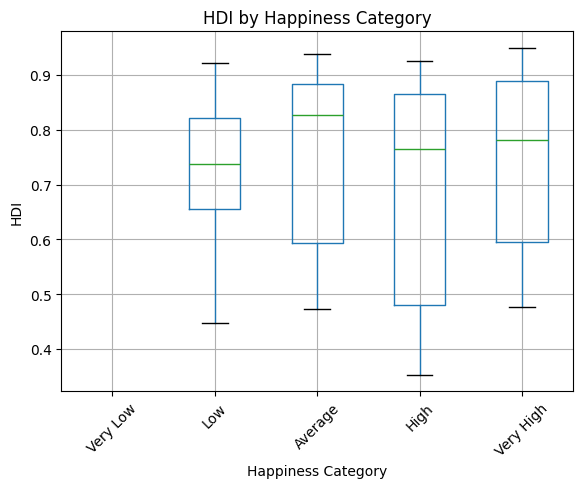

In [17]:
plt.figure(figsize=(8,5))
temp.boxplot(column="hdi", by="happiness_category", rot=45)
plt.title("HDI by Happiness Category")
plt.suptitle("")
plt.xlabel("Happiness Category")
plt.ylabel("HDI")
plt.show()

The boxplot shows the distribution of HDI across different happiness categories. Overall, there appears to be a positive relationship between HDI and happiness levels.

Countries in higher happiness categories generally have higher median HDI values, indicating that higher human development is associated with greater happiness.

However, the distributions still overlap across categories, suggesting that HDI alone does not fully explain differences in happiness levels.

The High happiness group shows wider variation, indicating that countries with similar happiness levels may still differ in their level of human development.

In [18]:
temp = X_train.copy()
temp["happiness_category_code"] = y_train.astype("category").cat.codes

corr_with_target = (
    temp.select_dtypes(include=["int64", "float64"])
        .corr()["happiness_category_code"]
        .sort_values(ascending=False)
        .to_frame(name="Correlation_with_Happiness_Category")
)

corr_with_target

,Correlation_with_Happiness_Category
happiness_category_code,1.000000
perceptions_of_corruption,0.162115
population_below_poverty_line,0.079533
expected_years_of_schooling,0.024791
gni,0.017251
mean_years_of_schooling,-0.001661
life_expectancy,-0.004647
hdi,-0.009183
generosity,-0.010237
gdp_per_capita,-0.016241


The correlation table shows the relationships between numerical predictors and the encoded happiness category. Overall, most variables display relatively weak linear correlations with the target.

The strongest positive correlation is observed for `perceptions_of_corruption` (r ≈ 0.16), while `population_below_poverty_line` shows a smaller positive relationship (r ≈ 0.08). In contrast, `population` exhibits the largest negative correlation with the encoded happiness category (r ≈ -0.26). Most other variables have correlations close to zero.

These results suggest that no single variable strongly determines happiness category on its own. Instead, happiness outcomes are likely influenced by multiple interacting socioeconomic factors.

It is important to interpret these correlations cautiously because the target variable represents categorical happiness groups rather than a truly continuous measure. As a result, Pearson correlations with the encoded labels may underestimate underlying relationships.

### Outlier Detection

Identify potential outliers in the numerical features using appropriate methods such as:

- Box plots
- Z-score analysis
- Interquartile Range (IQR) method

Highlight any significant anomalies and briefly comment on whether they should be retained, transformed, or removed.

In [19]:
num_df = X_train.select_dtypes(include=["int64","float64"])

outlier_counts = {}

for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((num_df[col] < lower_bound) | (num_df[col] > upper_bound)).sum()

    outlier_counts[col] = outliers

pd.Series(outlier_counts).sort_values(ascending=False)

perceptions_of_corruption        10
population                        9
population_below_poverty_line     4
freedom_to_make_life_choices      3
social_support                    2
gni                               2
gdp_per_capita                    1
generosity                        1
healthy_life_expectancy           0
hdi                               0
life_expectancy                   0
expected_years_of_schooling       0
mean_years_of_schooling           0
dtype: int64

The outlier detection using the IQR method shows that several numerical variables contain potential outliers. The variables with the highest number of outliers include perceptions_of_corruption, population, and population_below_poverty_line. These variables show values that fall outside the typical interquartile range of the data.

The presence of outliers in variables such as gni, gdp indicators is less. Some variables, including healthy_life_expectancy, HDI, and education-related variables, do not show significant outliers, indicating that these indicators are relatively more stable across countries.

Rather than removing these outliers, it is more appropriate to retain them because they represent real-world differences between countries. However, applying transformations such as logarithmic scaling to highly skewed variables may help reduce the influence of extreme values during model training.

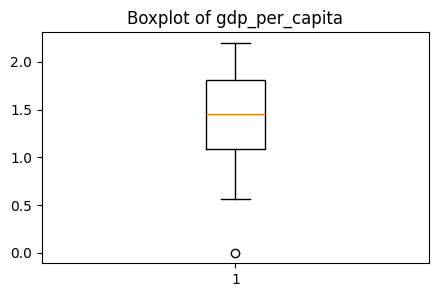

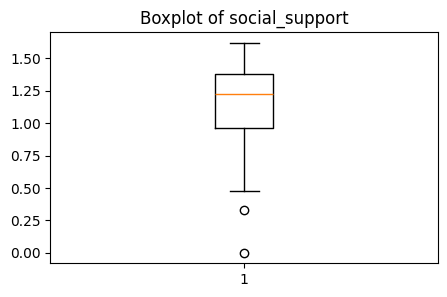

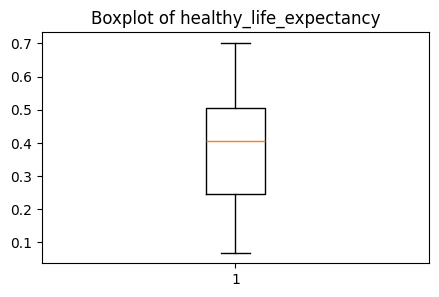

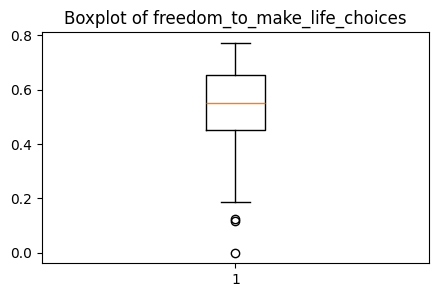

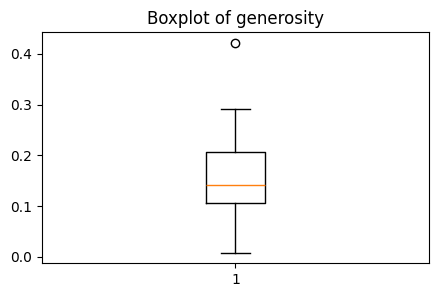

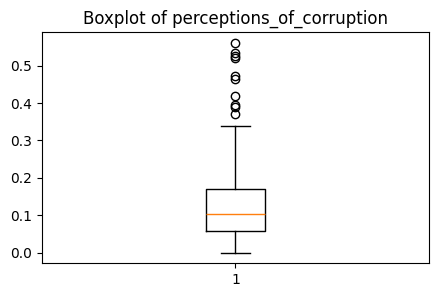

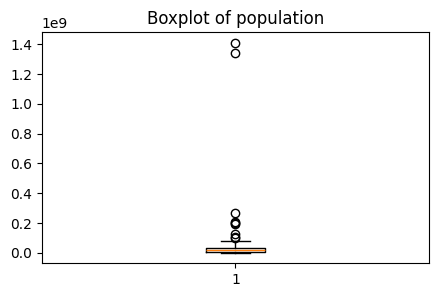

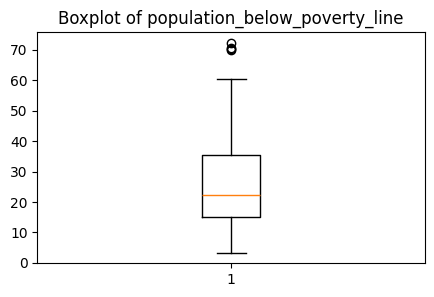

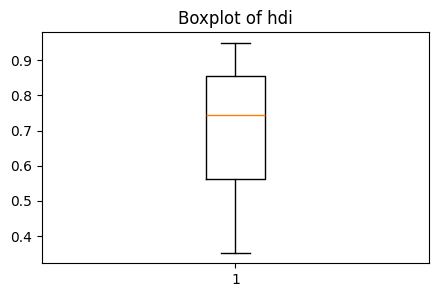

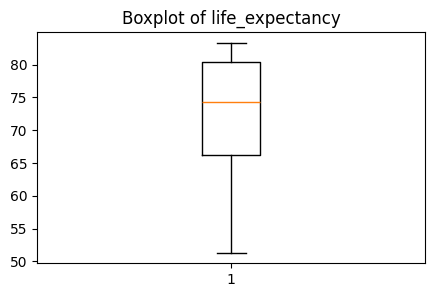

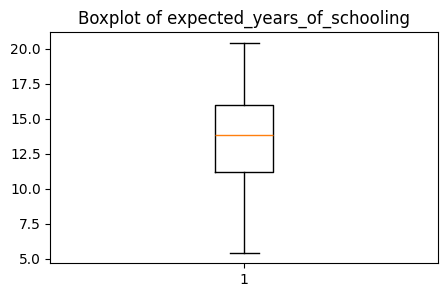

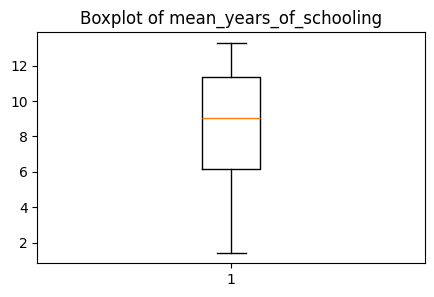

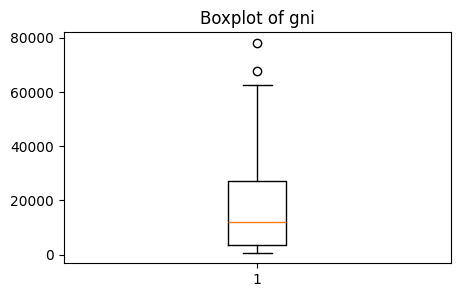

In [20]:
num_cols = num_df.columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(num_df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()

Although Z-score can be used to detect outliers, it assumes a roughly normal distribution of the data. Since several variables in this dataset (such as population and GNI) exhibit strong right-skewed distributions, the IQR method provides a more robust approach for identifying potential outliers.

### Observations and General Comments

Summarize your key findings from the exploratory analysis. Include:

- Important patterns or relationships identified
- Presence of missing values or outliers
- Potential feature engineering considerations
- Any preprocessing steps that should be applied before modeling

Keep your comments concise and evidence-based.

Overall, the exploratory analysis highlights several key findings.

First, development-related indicators such as GDP per capita, HDI, schooling measures, and life expectancy appear strongly related to one another, suggesting that they capture similar aspects of socioeconomic development.

Second, individual predictors show only modest direct relationships with the encoded happiness category. For example, the largest observed positive correlation is for perceptions_of_corruption (**r ≈ 0.16**), while population shows a moderate negative correlation (**r ≈ −0.26**). Most other variables have correlations close to zero.

Third, some variables such as population and gni exhibit strong right-skewed distributions, reflecting large differences between countries in population size and economic scale.

These findings suggest that predicting happiness categories will likely require models that capture relationships among multiple socioeconomic indicators rather than relying on any single predictor.
The exploratory data analysis reveals several important patterns and considerations for modeling.

First, strong positive relationships exist among several development-related variables. In particular, GDP per capita, HDI, life expectancy, and years of schooling show very high correlations with one another. This suggests that economic development and human development indicators tend to move together across countries. Additionally, social support and freedom to make life choices appear moderately correlated with these development indicators, which may also influence happiness outcomes.

Second, the dataset contains a moderate amount of missingness in some variables introduced through the merge, particularly population_below_poverty_line. However, the overall level of missingness remains manageable and can be handled through imputation during preprocessing. In addition, several variables show clear skewness and potential outliers, especially population and GNI. These extreme values are expected because some countries have much larger populations or higher income levels than others.

Third, the distribution plots indicate that several variables are right-skewed, particularly population and GNI. For this reason, applying log transformations to these variables would likely improve model stability and reduce the influence of extreme values.

Finally, several preprocessing steps should be applied before modeling. These include scaling numerical variables, encoding categorical variables such as region, and applying log transformations to skewed variables. Additionally, interaction terms between key socioeconomic indicators (for example, GDP per capita and social support) may help capture more complex relationships in the data.

Overall, the exploratory analysis suggests that the dataset contains meaningful relationships among development indicators and happiness outcomes, while also highlighting the importance of appropriate preprocessing and feature engineering prior to model training.

---

## 2. Feature Engineering

Apply log transformations to normalize skewed numerical features and improve model stability (if applicable).

In [21]:
import numpy as np

X_train["log_population"] = np.log1p(X_train["population"])
X_test["log_population"] = np.log1p(X_test["population"])

X_train["log_gni"] = np.log1p(X_train["gni"])
X_test["log_gni"] = np.log1p(X_test["gni"])

Create at least one interaction feature to capture relationships between existing variables and enhance predictive power.

In [22]:
X_train["gdp_social_interaction"] = (
    X_train["gdp_per_capita"] * X_train["social_support"]
)

X_test["gdp_social_interaction"] = (
    X_test["gdp_per_capita"] * X_test["social_support"]
)

---

## 3. Data Preprocessing

Use `sklearn`'s `ColumnTransformer` to preprocess the data. Write a preprocessing function and save the fitted preprocessor for later use.

In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create the preprocessing pipelines for both numeric and categorical data.

numeric_features = X_train.drop(columns=['country', 'country_name', 'region'])
numeric_features=numeric_features.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())])

categorical_features = ['region']

#Replacing missing values with Modal value and then one hot encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# final preprocessor object set up with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

#Fit your preprocessor object
preprocess=preprocessor.fit(X_train)

preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Explanation

Briefly explain what the preprocessing steps above do and why they are needed.

If you changed the imputation strategy (or any other preprocessing choice), please state:

- What you changed
- Why you made that change

We use the ColumnTransformer class to carry out the data preprocessing for the numeric and categorical features. Here, we exclude the text/ID columns (country & country_name) from the modeling workflow and consider region as the only categorical feature. The one-hot encoding is carried out with handle_unknown="ignore" to ensure that when any new categories are encountered in the test data, they do not raise KeyError during the prediction. We then use the fillna() function from pandas to replace the missing values in the numeric variables with a constant value of 0. Finally, we use StandardScaler to scale and normalize all variables. This is done to ensure that all variables are of the same scale which improves the stability of the model.

In [24]:
# function to transform data with preprocessor

def preprocessor(data):
    data.drop(['country', 'region'], axis=1)
    preprocessed_data=preprocess.transform(data)
    return preprocessed_data

### Conceptual Question

Explain the differences between the following:

- The `preprocessor` **object**
- The `preprocess` **object**
- The `preprocessor` **function**
- The final `preprocessed_data` **returned**

Clearly distinguish between objects, functions, and transformed data.

Preprocessor Object: The recipe for preprocessing (a ColumnTransformer with pipelines). We know which operations we want to perform on which types of columns (e.g. impute, scale, one-hot encode) but the preprocessor object has not yet been fit to the data so it does not contain any learned statistics/mappings.

Preprocess Object: the fitted version of that recipe (i.e. the result of preprocessor.fit(X_train)). Once a recipe has been trained, the preprocess object knows all of the appropriate values for any missing values that need to be imputed, the coefficients to multiply each feature by to scale the features, the name of the column to use in a one-hot encoding, etc. The purpose of this object is to take any other dataset with the same characteristics as the training set and transform it in a way that's compatible with the model that was learned from the training set.

Preprocessor Function: A Python function you wrote as a wrapper. This function will take the data, remove unwanted columns and then pass it to the preprocess.transform(data) method. Then it applies the same transformation on the training data again. This way you make sure that the steps you applied remain intact and within control, and also keep the steps in one place.

preprocessed_data Returned: the output data after transformation—That is the data after it has been modified in some way. Here it will be in the form of a numeric matrix (which can be sparse) ready to be trained on or used for prediction. The output will be in the form of scaled numeric features along with the one-hot encoded categorical variables.

In [25]:
# check shape of X data after preprocessing it using our new function
preprocessor(X_train).shape

(95, 26)

---

## 4. Model Training and Saving Artifacts

Fit the model on the preprocessed training data. Save the fitted preprocessor and the trained model for reuse (e.g., inference and submission).

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=500,random_state=42,n_jobs=-1)

X_train_pp = preprocessor(X_train.copy())
model.fit(X_train_pp, y_train)

X_test_pp = preprocessor(X_test.copy())
score = model.score(X_test_pp, y_test)
score

0.5476190476190477

In [27]:
import os, joblib
os.makedirs("artifacts", exist_ok=True)
joblib.dump(preprocess, "artifacts/preprocess.joblib")
joblib.dump(model, "artifacts/model_rf.joblib")

['artifacts/model_rf.joblib']

---

## 5. Model Evaluation

Generate predictions using `X_test`. Compare the predictions with the true labels in `y_test` using appropriate evaluation metrics.

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#-- Generate predicted values (Model 1)
prediction_labels = model.predict(preprocessor(X_test.copy()))

# Model performance
acc = accuracy_score(y_test, prediction_labels)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, prediction_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction_labels))

Accuracy: 0.5476190476190477

Classification Report:
              precision    recall  f1-score   support

     Average       0.60      0.75      0.67         8
        High       0.62      0.62      0.62         8
         Low       0.33      0.50      0.40         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.40      0.22      0.29         9

    accuracy                           0.55        42
   macro avg       0.56      0.55      0.55        42
weighted avg       0.57      0.55      0.54        42


Confusion Matrix:
[[6 1 1 0 0]
 [2 5 0 1 0]
 [1 0 4 0 3]
 [1 2 0 6 0]
 [0 0 7 0 2]]


---

## 6. Hyperparameter Experimentation

Repeat the training and evaluation process with different model parameters to improve performance. Track results across experiments and report the best-performing configuration.

In [29]:
# Train another model using same preprocessor (note that you could save a new preprocessor, but we will use the same one for this example).
from sklearn.ensemble import RandomForestClassifier

# Try different hyperparameters: more trees, different depth, more samples per leaf
model_guess_hyperparameter = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2, random_state=42, n_jobs=-1)

X_train_pp = preprocessor(X_train.copy())
model_guess_hyperparameter.fit(X_train_pp, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Reflection on Hyperparameter Changes

Briefly explain:

- What parameters you changed
- What each parameter controls
- Why the changes improved (or did not improve) performance

Support your explanation with evidence from your results.

For the Random Forest model with hyperparameter changes, we modified three parameters: n_estimators, max_depth, and min_samples_leaf. These changes are reflected in the parameters of RandomForestClassifier. The text in red shows values that we specifically set. As you can see, all these values are explicitly set, alongside n_jobs and random_state, which remain the same from the original Random Forest model.

We decreased n_estimators from 500 to 300. This reduced the number of trees in the forest. While fewer trees reduces the risk of overfitting, it can also decrease stability.

Additionally, we set a max_depth. Originally, it was left at the default, though we specifically set it to 12 for the modified Random Forest model. This parameter controls the maximum depth of each tree. While lower values can limit complexity, higher values can run the risk of overfitting. The original default value means that the tree grows until purity or min_samples_split.

Finally, we changed min_samples_leaf from the default to 2. This controls the minimum number of samples in each leaf. A larger value increases the size of the leaf, which can make the model smoother and improve generalization.

As a result of the changes we made, performance improved. The original Random Forest model had a test accuracy of 54.8%, while the Random Forest model with hyperparameter changes achieved an accuracy of 57.1%, representing a 2.3% increase. This is consistent with the changes we made to the parameters. Setting max_depth and min_samples_leaf limits the depth of each tree and prevents very small leaves, which makes the forest simpler. Reducing the number of trees also helped avoid overfitting given our limited dataset. Ultimately, this suggests that the original Random Forest model was likely overfitting and not generalizing well, which is why these changes improved the accuracy of the modified Random Forest model.

In [30]:
#Evaluate Model 2 (model_guess_hyperparameter):

# Generate predicted y values
prediction_labels = model_guess_hyperparameter.predict(preprocessor(X_test.copy()))

# Write lines of code below to show model performance by comparing prediction_labels with true labels
print("Model 2 Accuracy:", accuracy_score(y_test, prediction_labels))
print("\nClassification Report:\n", classification_report(y_test, prediction_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test, prediction_labels))



Model 2 Accuracy: 0.5714285714285714

Classification Report:
               precision    recall  f1-score   support

     Average       0.60      0.75      0.67         8
        High       0.62      0.62      0.62         8
         Low       0.38      0.62      0.48         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.50      0.22      0.31         9

    accuracy                           0.57        42
   macro avg       0.59      0.58      0.57        42
weighted avg       0.60      0.57      0.56        42

Confusion Matrix:
 [[6 1 1 0 0]
 [2 5 0 1 0]
 [1 0 5 0 2]
 [1 2 0 6 0]
 [0 0 7 0 2]]


### Discussion Question

Do you think it is worth making more changes to the parameters? Should we keep trying random values and see what works better? What is an alternative to doing this manually?

So far, we have seen that parameter changes has meaningfully improved test accuracy from 0.548 (Model 1, Random Forest) to 0.571 (Model 2, Random Forest with guessed parameter changes), exemplifying that tuning does help. Therefore, we think it is still beneficial to try changing the parameters.

That being said, random value selection by hand is not necessarily the best idea. It is slow and runs the risk of missing good settings. With our small dataset, it is easy to overfit.

Thus, our best method is to automate the search. This can be done using the tool GridSearchCV. This incredible tool lets us define a grid of values for our parameters we are willing to tweak, and the algorithm trains and compares the many combinations using cross-validation. In this way, we can systematically pick the best configuration and minimize the wasted time from one-shot, random-pick approaches.

In [31]:
# Submit a third model using GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Search over a few key hyperparameters
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 2, 4]
}

# Base classifier with fixed random_state for reproducibility
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search with 5-fold cross-validation
gridmodel = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Preprocess training and test data
X_train_pp = preprocessor(X_train.copy())
X_test_pp = preprocessor(X_test.copy())

# Fit GridSearchCV on training data
gridmodel.fit(X_train_pp, y_train)

# Extract best score and best parameters
print("Best mean cross-validation score: {:.3f}".format(gridmodel.best_score_))
print("Best parameters: {}".format(gridmodel.best_params_))

# Get the best trained Random Forest model
best_rf = gridmodel.best_estimator_

# Make predictions on the test set
prediction_labels = best_rf.predict(X_test_pp)

# Evaluate test performance
print("Test accuracy: {:.4f}".format(accuracy_score(y_test, prediction_labels)))
print("\nClassification Report:")
print(classification_report(y_test, prediction_labels))
print("Confusion Matrix:")
print(confusion_matrix(y_test, prediction_labels))


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best mean cross-validation score: 0.547
Best parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}
Test accuracy: 0.5714

Classification Report:
              precision    recall  f1-score   support

     Average       0.60      0.75      0.67         8
        High       0.62      0.62      0.62         8
         Low       0.38      0.62      0.48         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.50      0.22      0.31         9

    accuracy                           0.57        42
   macro avg       0.59      0.58      0.57        42
weighted avg       0.60      0.57      0.56        42

Confusion Matrix:
[[6 1 1 0 0]
 [2 5 0 1 0]
 [1 0 5 0 2]
 [1 2 0 6 0]
 [0 0 7 0 2]]


In [32]:
# Submit Model 3: GridSearchCV Random Forest

# Generate predicted values using the best model found by GridSearchCV
prediction_labels = best_rf.predict(X_test_pp)

# Show model performance
print("Model 3 (GridSearch best) Accuracy:", accuracy_score(y_test, prediction_labels))
print("\nClassification Report:\n", classification_report(y_test, prediction_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test, prediction_labels))



Model 3 (GridSearch best) Accuracy: 0.5714285714285714

Classification Report:
               precision    recall  f1-score   support

     Average       0.60      0.75      0.67         8
        High       0.62      0.62      0.62         8
         Low       0.38      0.62      0.48         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.50      0.22      0.31         9

    accuracy                           0.57        42
   macro avg       0.59      0.58      0.57        42
weighted avg       0.60      0.57      0.56        42

Confusion Matrix:
 [[6 1 1 0 0]
 [2 5 0 1 0]
 [1 0 5 0 2]
 [1 2 0 6 0]
 [0 0 7 0 2]]


#### Testing GradientBoostingClassifier (with GridSearchCV)

Given GridSearchCV was beneficial in maximizing accuracy, we also implemented it in our testing of GradientBoostingClassifier.

In [33]:
# Here are several classic ML architectures you can consider choosing from to experiment with next:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Use GradientBoostingClassifier with GridSearchCV to tune hyperparameters
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_leaf': [1, 2],
}
grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
X_train_pp = preprocessor(X_train.copy())
grid_gb.fit(X_train_pp, y_train)

print("Best mean CV score: {:.3f}".format(grid_gb.best_score_))
print("Best parameters:", grid_gb.best_params_)

#-- Generate predicted values using the best estimator
model = grid_gb.best_estimator_
prediction_labels = grid_gb.predict(preprocessor(X_test.copy()))

## Write lines of code to show model performance by comparing prediction_labels with true labels
print("\nGradientBoosting (GridSearch best) Accuracy:", accuracy_score(y_test, prediction_labels))
print("\nClassification Report:\n", classification_report(y_test, prediction_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test, prediction_labels))


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best mean CV score: 0.568
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 50}

GradientBoosting (GridSearch best) Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

     Average       0.60      0.75      0.67         8
        High       0.56      0.62      0.59         8
         Low       0.22      0.25      0.24         8
   Very High       0.75      0.67      0.71         9
    Very Low       0.33      0.22      0.27         9

    accuracy                           0.50        42
   macro avg       0.49      0.50      0.49        42
weighted avg       0.49      0.50      0.49        42

Confusion Matrix:
 [[6 1 1 0 0]
 [1 5 0 2 0]
 [2 0 2 0 4]
 [1 2 0 6 0]
 [0 1 6 0 2]]


### Discussion Question

Describe the parameters you defined in `GradientBoostingClassifier`, and/or `BaggingClassifier`, and/or `KNN`, and/or `SVC`. What worked and why?

We chose to run GradientBoostingClassifier. We defined three parameters: n_estimators, max_depth, and random_state.

We set n_estimators to 100, which essentially sets the number of boosting stages or trees. Each stage is fit based on the previous stage.

We also set max_depth to 4, which kept the trees rather shallow and reduced the chance of overfitting.

Finally, we set random_state to 42 so we could reproduce our results.

Ultimately, we found that the GradientBoosting model underperformed the Random Forest models, achieving an accuracy of around 50%. While Gradient Boosting is often a strong ensemble method, it can require more data to fully capture patterns in the dataset. Because our dataset is relatively small, the model may not have had enough information to build strong sequential trees. Additionally, although we used GridSearchCV to tune several hyperparameters, the configuration we found did not perform as well as the tuned Random Forest model. It is also possible that further tuning of other hyperparameters, such as learning_rate or additional tree parameters, could improve performance.

---

## 7. Basic Deep Learning

In [34]:
# Now experiment with deep learning models:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
import numpy as np

# Preprocess input features (same pipeline as for the RF model)
X_train_nn = preprocessor(X_train.copy())

feature_count = X_train_nn.shape[1]  # number of columns after preprocessing (numeric + one-hot region)

# Define a Neural Network Model with 5 layers 128 -> 64 -> 64 -> 32 -> 5 (one neuron per class)
# Use Softmax in the last layer so we get class probabilities; 5 neurons for 5 happiness categories
keras_model = Sequential([
    Dense(128, activation='relu', input_shape=(feature_count,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

# Create categorical labels to use categorical_crossentropy
y_train_oh = pd.get_dummies(y_train)

# Compile model
keras_model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Fitting the NN to the Training set, store history
history = keras_model.fit(X_train_nn, y_train_oh,
               batch_size=20,
               epochs=300, validation_split=0.25)

c:\Users\AoifeTurner\QMSS\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.1690 - loss: 1.6084 - val_accuracy: 0.2500 - val_loss: 1.6592
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2113 - loss: 1.5909 - val_accuracy: 0.2083 - val_loss: 1.6543
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2394 - loss: 1.5735 - val_accuracy: 0.2083 - val_loss: 1.6488
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2535 - loss: 1.5569 - val_accuracy: 0.2083 - val_loss: 1.6447
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2676 - loss: 1.5417 - val_accuracy: 0.2083 - val_loss: 1.6406
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2676 - loss: 1.5267 - val_accuracy: 0.2083 - val_loss: 1.6368
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3380 - loss: 1.5140 - val_accuracy: 0.2083 - val_loss: 1.6334
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3521 - loss: 1.5004 - val_accuracy: 0.2500 - val_loss:

### Discussion Question

Which activation functions did you use in the hidden layers? Why was **softmax** used in the final layer?

In our hidden layers, we used ReLu activation functions. This is a common activation function that introduces non-linearity through a single kink between two lines (one flat, one non-flat). This lets the model learn the complex relationship between features, and is computationally efficient.

For the final layer, we used softmax because we were trying to run a multi-class classification with 5 happiness categories. By using softmax, we converted the output of our final layer into a probability distribution across the five classes. Each value was the probability that a given input belonged to that class, where all probabilities summed to 1.

### Discussion Question

Was it a good idea to train for 300 epochs? Should you train longer? Why or why not?

Training for 300 epochs was not a good decision, and further training is not needed. Initially, the training accuracy increased dramatically and the training loss decreased, exemplifying that the model was learning from the training set well. However, overtime, the validation accuracy stayed low between 25-41% (even showing more low troughs as the epochs increased), while the validation loss increased over time (even reaching 1.96) from ~1.6.

This shows patterns of overfitting, where the model is memorizing training data rather than actually learning data that can be generalized with new test data. Validation performance stopped improving and actually began getting worse (epoch 91 had 0.5000 validation accuracy, while epoch 300 had 0.4167), so if we chose to continue to train our model, overfitting would only worsen along with performance.

Thus, we should stop training early when validation loss stops improving (reduce number of epochs), or reduce model complexity. This number of epochs that we will continue using for the rest of the paper is described below under the plotted training curves, we there we can see how loss changes depending to epoch count.

### Discussion Question

Why was `loss='categorical_crossentropy'` and `optimizer='sgd'` used? Would you change anything? Why or why not?

We used categorical_crossentropy because the problem had 5 classes, and each label was one-hot encoded. This loss function worked well with the softmax output and measured how well the predicted class probabilities match the true class. Meanwhile, sgd (Stochastic Gradient Descent) was used as an optimizer to update the weights during training. Based on the performance, We'd replace this with adam, which often performs better with less tuning. We would keep the categorical_crossentropy as a way to calculate loss, though would definitely implement an algorithm that checks validation loss and stops training in a timely way to reduce the overfitting previously mentioned.

### Plot Training Curves

Extract the model training history and plot the learning curves (e.g., training vs. validation loss and accuracy) across epochs.

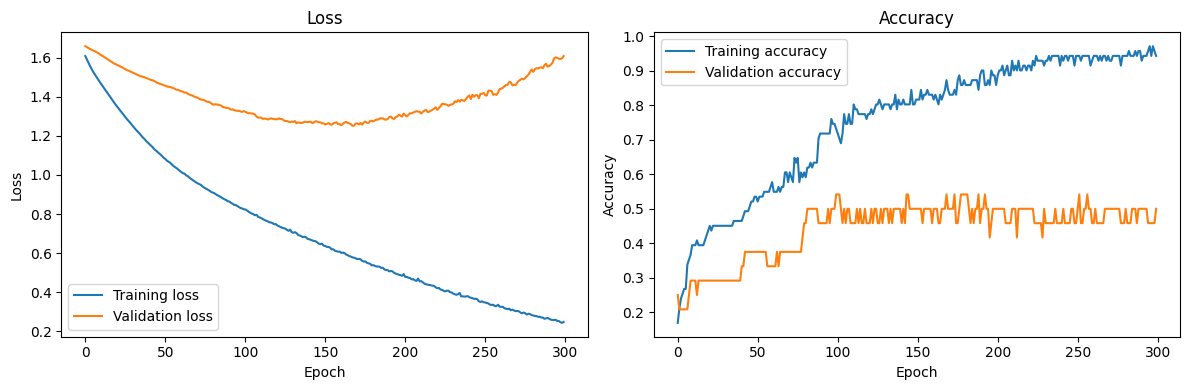

In [35]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Training loss')
ax1.plot(history.history['val_loss'], label='Validation loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss')

ax2.plot(history.history['accuracy'], label='Training accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Accuracy')

plt.tight_layout()
plt.show()

#### How Many Epochs is Best?
Averaged across five runs (it changes slightly), we found our validation loss is minimized at around 100, as generally reflected by our graph. We see it decreasing initially, indicating that our model is learning properly and pulling useful patterns from the data. After 100, though, it begins to increase steadily, indicating that our model start overfitting. Therefore, we will be only running our NN model through 100 epochs.

In [36]:
#-- Generate predicted y values

# Note: Keras predict returns class probabilities; we take argmax to get the predicted class index
X_test_nn = preprocessor(X_test.copy())
pred_proba = keras_model.predict(X_test_nn)
prediction_column_index = np.argmax(pred_proba, axis=1)

# extract correct prediction labels (same order as one-hot columns: Very Low, Low, Average, High, Very High)
prediction_labels = [y_train_oh.columns[i] for i in prediction_column_index]

## Write lines of code to show model performance by comparing prediction_labels with true labels
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Keras model Accuracy:", accuracy_score(y_test, prediction_labels))
print("\nClassification Report:\n", classification_report(y_test, prediction_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test, prediction_labels))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Keras model Accuracy: 0.6428571428571429

Classification Report:
               precision    recall  f1-score   support

     Average       0.55      0.75      0.63         8
        High       0.67      0.50      0.57         8
         Low       0.57      0.50      0.53         8
   Very High       1.00      0.78      0.88         9
    Very Low       0.55      0.67      0.60         9

    accuracy                           0.64        42
   macro avg       0.67      0.64      0.64        42
weighted avg       0.67      0.64      0.65        42

Confusion Matrix:
 [[6 1 0 0 1]
 [4 4 0 0 0]
 [0 0 4 0 4]
 [1 1 0 7 0]
 [0 0 3 0 6]]


### Regularization: Dropout and Batch Normalization

Implement regularization techniques such as **Dropout** and **Batch Normalization** to improve generalization and observe the change in performance.

> **Note:** Compare training vs. test (or validation) loss and accuracy before and after adding regularization.

In [37]:
# Build and train model with Dropout and Batch Normalization (for comparison with original)
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization

model_bn = Sequential([
    Dense(128, activation='relu', input_shape=(feature_count,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(5, activation='softmax')
])
model_bn.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
history2 = model_bn.fit(X_train_nn, y_train_oh, batch_size=20, epochs=100, validation_split=0.25)

Epoch 1/100


c:\Users\AoifeTurner\QMSS\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.1268 - loss: 2.6873 - val_accuracy: 0.1250 - val_loss: 1.6089
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2535 - loss: 2.2523 - val_accuracy: 0.2917 - val_loss: 1.6094
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1831 - loss: 2.2162 - val_accuracy: 0.2500 - val_loss: 1.6182
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2535 - loss: 2.0284 - val_accuracy: 0.2083 - val_loss: 1.6117
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2817 - loss: 1.8681 - val_accuracy: 0.2917 - val_loss: 1.6128
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2817 - loss: 1.8659 - val_accuracy: 0.1667 - val_loss: 1.6190
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3380 - loss: 1.6528 - val_accuracy: 0.1667 - val_loss: 1.6116
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2535 - loss: 1.9163 - val_accuracy: 0.1667 - val_loss: 1.6118
Epoc

Best stopping epoch for Dropout + BatchNorm model: 39 (val_loss = 1.5748)


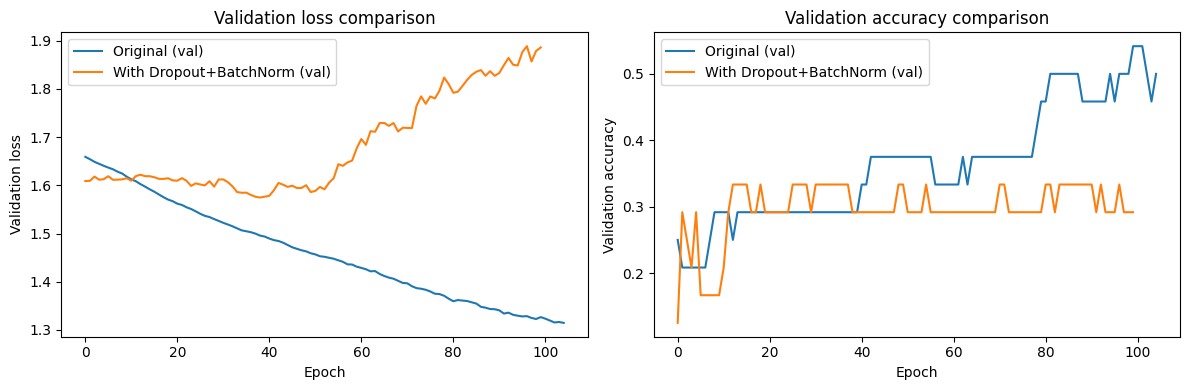

In [38]:
# Plotting Original vs. With Dropout + BatchNorm

import numpy as np

stop_epoch = 105

# Find best stopping epoch for the regularized model
best_epoch_bn = np.argmin(history2.history['val_loss']) + 1
best_val_loss_bn = history2.history['val_loss'][best_epoch_bn - 1]

print(f"Best stopping epoch for Dropout + BatchNorm model: {best_epoch_bn} (val_loss = {best_val_loss_bn:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['val_loss'][:stop_epoch], label='Original (val)', color='C0')
axes[0].plot(history2.history['val_loss'][:stop_epoch], label='With Dropout+BatchNorm (val)', color='C1')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation loss')
axes[0].legend()
axes[0].set_title('Validation loss comparison')

axes[1].plot(history.history['val_accuracy'][:stop_epoch], label='Original (val)', color='C0')
axes[1].plot(history2.history['val_accuracy'][:stop_epoch], label='With Dropout+BatchNorm (val)', color='C1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation accuracy')
axes[1].legend()
axes[1].set_title('Validation accuracy comparison')

plt.tight_layout()
plt.show()

#### Reflection of Dropout & Batch Normalization
After adding Dropout and Batch Normalization, the validation loss decreases slightly initially, then begins to increase a bit earlier around epoch 60. This is expected, given that Dropout intentionally makes training noisier by randomly turning off neurons during training, and learning is slower. As a result, the model reaches best vaidation earlier in training.

That being said, we do not think that Dropout and Batch Normalization are a beneficial addition, as the regularized model achieved a similar validation accuracy. Additionally, validation loss was in general significantly higher than the original for all values past around 10 epochs. So for our small dataset, adding Batch Normalization + Dropout appears to not truly help overall, even when the model is stopped at the appropriate epoch.

### Activation Function Experimentation

Experiment with different activation functions — **ReLU**, **LeakyReLU**, **Tanh**, and **Sigmoid** — and compare their impact on model performance.

c:\Users\AoifeTurner\QMSS\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\AoifeTurner\QMSS\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\AoifeTurner\QMSS\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
c:\Users\AoifeTurner\QMSS\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`in

Final validation accuracy:
  ReLU: 0.2917
  LeakyReLU: 0.3333
  Tanh: 0.4167
  Sigmoid: 0.1250


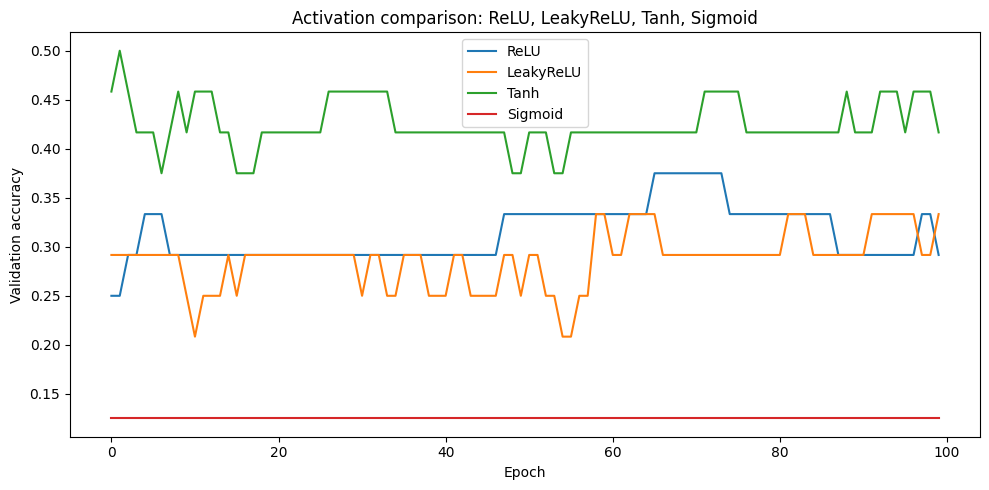

In [41]:
# Compare ReLU, LeakyReLU, Tanh, and Sigmoid (same architecture, different activations in hidden layers)
from keras.layers import LeakyReLU
import matplotlib.pyplot as plt

def build_model(hidden_activation):
    """Build Sequential model with given activation for hidden layers."""
    if hidden_activation == 'leaky_relu':
        model = Sequential([
            Dense(128, input_shape=(feature_count,)),
            LeakyReLU(alpha=0.3),
            Dense(64),
            LeakyReLU(alpha=0.3),
            Dense(64),
            LeakyReLU(alpha=0.3),
            Dense(32),
            LeakyReLU(alpha=0.3),
            Dense(5, activation='softmax')
        ])
    else:
        model = Sequential([
            Dense(128, activation=hidden_activation, input_shape=(feature_count,)),
            Dense(64, activation=hidden_activation),
            Dense(64, activation=hidden_activation),
            Dense(32, activation=hidden_activation),
            Dense(5, activation='softmax')
        ])

    model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model


histories = {}

# Train all activations for 100 epochs
for act_name, act in [
    ('ReLU', 'relu'),
    ('LeakyReLU', 'leaky_relu'),
    ('Tanh', 'tanh'),
    ('Sigmoid', 'sigmoid')
]:
    m = build_model(act)
    h = m.fit(
        X_train_nn,
        y_train_oh,
        batch_size=20,
        epochs=100,
        validation_split=0.25,
        verbose=0
    )
    histories[act_name] = h


# Print final validation accuracy
print('Final validation accuracy:')
for name, h in histories.items():
    print(f'  {name}: {h.history["val_accuracy"][-1]:.4f}')


# Plot validation accuracy
plt.figure(figsize=(10,5))
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'], label=name)

plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Activation comparison: ReLU, LeakyReLU, Tanh, Sigmoid')
plt.legend()
plt.tight_layout()
plt.show()

#### Results from Graph

Based on our results, we found the graph misleading. 

Realistically, we found that LeakyReLu, ReLu, and Tanh performed about the same for the bits we are concerned. While in this run, Tanh appears to be significantly better than the other three, it is not always the case. This is highly dependent on runs and appears to fluctuate between ReLu, Leaky ReLu, and Tanh, arguing that perhaps one is not necessarily "better" than the other and it is highly volatile and run-dependent. It appears that there is not "one" winner, and this is likely due to the small size of the validation set. Therefore, accuracy keeps jumping discreetely and perhaps not fully accurate.
That being said, Sigmoid seems to be significantly worse than all other tests, nearly bottomed out the entire test. We will ignore Sigmoid at all costs, as it likely failed due to the vanishing gradient problem.

---

## 8. Explainability – SHAP Feature Importance

To better understand the model's predictions, we will use **SHAP (SHapley Additive exPlanations)** to analyze feature importance.

**How SHAP works:**

- SHAP assigns each feature a contribution score for every prediction.
- It uses Shapley values (from cooperative game theory) to fairly distribute importance across features.

We will apply SHAP to visualize and interpret the model's feature contributions.

#### What model did we run SHAP on?

We chose to run SHAP testing on best_rf, which was our Random Forest model with hyperparameters selected by GridSearchCV tests. We chose this model because, thus far, it has outperformed all other models with an accuracy comfortably over 50%, while the rest (Gradient Boosting Classifier, fully-connected neural network with keras, neural network with dropout and batch normalization) has underperformed, not even reaching accuracies above 50%.

We hope to put our eggs in the most successful basket.

In the SHAP summary plot, low feature values are blue and high feature values are red.


C:\Users\AoifeTurner\AppData\Local\Temp\ipykernel_30620\3340790733.py:43: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 0], X_test_pp, feature_names=feature_names, show=False)


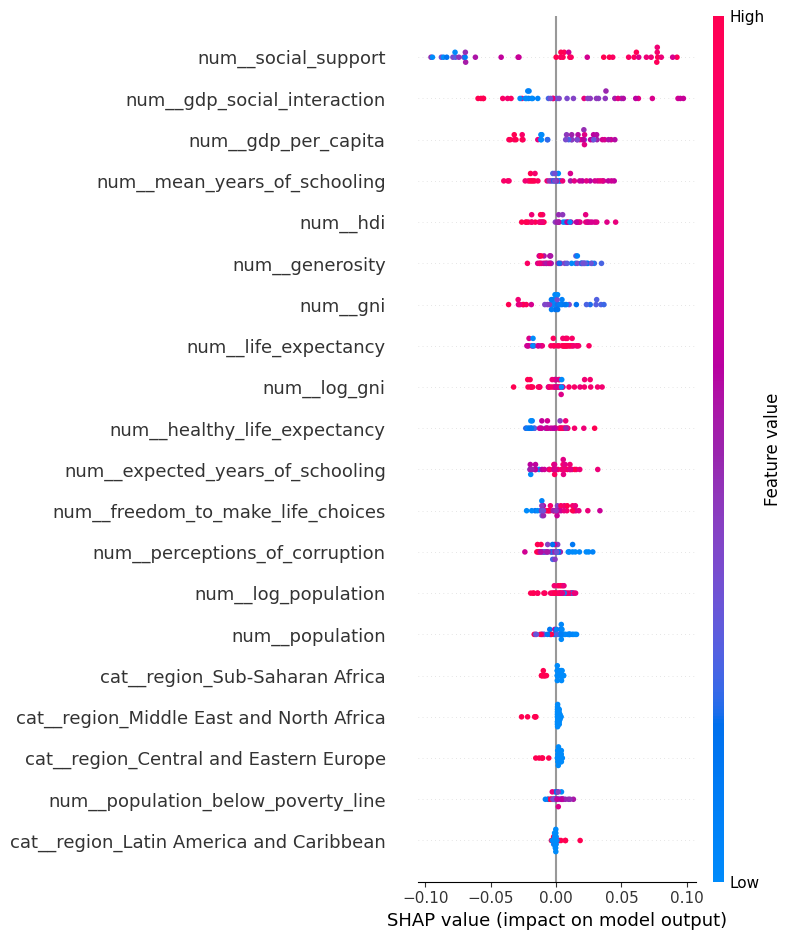

In [42]:
# Import necessary libraries
import shap
import matplotlib.pyplot as plt
import numpy as np
import joblib

# Use the same preprocessing as for training
# Load fitted preprocessor from artifacts if available
try:
    preprocess_shap = joblib.load("artifacts/preprocess.joblib")
except Exception:
    preprocess_shap = preprocess

def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

# Transform training and test data
X_train_pp = _to_dense(preprocess_shap.transform(X_train.copy()))
X_test_pp = _to_dense(preprocess_shap.transform(X_test.copy()))

# Use the best Random Forest model
model_for_shap = best_rf

# Use a sample of training data as SHAP background
background_size = min(100, len(X_train_pp))
np.random.seed(42)
background_idx = np.random.choice(len(X_train_pp), size=background_size, replace=False)
background = X_train_pp[background_idx]

# Build SHAP explainer and compute SHAP values
explainer = shap.TreeExplainer(model_for_shap, background)
shap_values = explainer.shap_values(X_test_pp)

# Feature names from the fitted preprocessor
feature_names = preprocess_shap.get_feature_names_out()

print("In the SHAP summary plot, low feature values are blue and high feature values are red.")

# Plot SHAP summary
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[0], X_test_pp, feature_names=feature_names, show=False)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap.summary_plot(shap_values[:, :, 0], X_test_pp, feature_names=feature_names, show=False)
else:
    shap.summary_plot(shap_values, X_test_pp, feature_names=feature_names, show=False)

plt.tight_layout()
plt.show()

Deep learning models are often considered "black boxes" due to their complexity. Use SHAP to explain your model's predictions.

After applying SHAP, discuss:

- Does it provide a clear and sufficient explanation of how the model makes decisions?
- How easy or difficult is it to justify your model's predictions using this technique?

SHAP provides somewhat clear explanations on how our model makes decisions. SHAP explains model predictions by assigning each feature a contribution value that shows how much it pushes the prediction higher or lower. It does this using Shapley values from game theory, which fairly distribute the model’s prediction across all input features.

Our best model (thus far) predictions can be explained with SHAP. For starters, we can pull some insights from what we see above. In the plot, red dots represent higher feature values while blue dots represent lower feature values, helping us see how the magnitude of each feature affects the model’s prediction.

Top Three Features:

Social support, or num_social_support, seems to be the most influential feature, as it has the largest spread of SHAP. Higher social support is associated with higher happiness categories for the model.

GDP and social support (num_gdp_social_interaction) also have a large impact. This means that economic comfort combined with societal support is very influential to happiness for our model.

GDP per capita seems to be an important feature. If our model has higher GDP values, they are associated with positive SHAP values, so they increase happiness for our model.

Bottom Features:

It appears that our model thinks that regional features and population variables do not have large impacts on our model's guesses for happiness. This is seen with the SHAP values all bunched near zero.

Overall, SHAP analysis argues that our model thinks that economic development and social factors are the most important in predicting happiness, while regional features are less impactful.

Given we are new to SHAP, we found it rather difficult to do in-depth analysis, given we were overwhelmed with clusters and colors, along with different levels. However, once we got the hang of it, we found it much easier than we had expected. It was especially useful that we were able to sort it by high feature value on the top, giving us a nice visualization of what features were most impactful.


### Experimentation

For experimentation, we decided to try out KNN and SVC models. Currently, our best model with the highest accuracy is our Random Forest model with Grid Search CV hyperparameters, outperforming our Gradient Boosting Classifier model and all of our fully-connected neural network models with keras. However, even then, the accuracy was ~57.14. We believe we can do better.

#### 8.1 Proprecessing and KNN

In [43]:
# Experimentation: KNN with same preprocessor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Same preprocessed splits as earlier sections
X_train_pp = preprocessor(X_train.copy())
X_test_pp = preprocessor(X_test.copy())

if hasattr(X_train_pp, "toarray"):
    X_train_pp = X_train_pp.toarray()
    X_test_pp = X_test_pp.toarray()

# KNN model
knn = KNeighborsClassifier(n_neighbors=15, weights="distance", metric="minkowski", p=2)

knn.fit(X_train_pp, y_train)

knn_pred = knn.predict(X_test_pp)

print("=== KNN (n_neighbors=15, weights=distance) ===")
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("\nClassification Report:\n", classification_report(y_test, knn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))

=== KNN (n_neighbors=15, weights=distance) ===
KNN Accuracy: 0.5952380952380952

Classification Report:
               precision    recall  f1-score   support

     Average       0.47      0.88      0.61         8
        High       0.57      0.50      0.53         8
         Low       0.50      0.62      0.56         8
   Very High       1.00      0.67      0.80         9
    Very Low       0.75      0.33      0.46         9

    accuracy                           0.60        42
   macro avg       0.66      0.60      0.59        42
weighted avg       0.67      0.60      0.59        42

Confusion Matrix:
 [[7 1 0 0 0]
 [4 4 0 0 0]
 [2 0 5 0 1]
 [1 2 0 6 0]
 [1 0 5 0 3]]


#### 8.2 SVC

In [44]:
# Experimentation: SVC
from sklearn.svm import SVC

svc = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)

svc.fit(X_train_pp, y_train)

svc_pred = svc.predict(X_test_pp)

print("\n=== SVC (RBF kernel, C=1, gamma=scale) ===")
print("SVC Accuracy:", accuracy_score(y_test, svc_pred))
print("\nClassification Report:\n", classification_report(y_test, svc_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svc_pred))


=== SVC (RBF kernel, C=1, gamma=scale) ===
SVC Accuracy: 0.5952380952380952

Classification Report:
               precision    recall  f1-score   support

     Average       0.54      0.88      0.67         8
        High       0.56      0.62      0.59         8
         Low       0.45      0.62      0.53         8
   Very High       1.00      0.56      0.71         9
    Very Low       0.75      0.33      0.46         9

    accuracy                           0.60        42
   macro avg       0.66      0.60      0.59        42
weighted avg       0.67      0.60      0.59        42

Confusion Matrix:
 [[7 1 0 0 0]
 [3 5 0 0 0]
 [2 0 5 0 1]
 [1 3 0 5 0]
 [0 0 6 0 3]]


On a side note, the confusion matrices for both KNN and SVC also show that our model is best at predicting the Average happiness category, correctly classifying most observations in that group, which aligns with the high recall of 0.88. The High and Low categories show moderate performance, with several correct predictions but some confusion with neighboring categories such as Average. The model also identifies some Very High cases correctly, while recall is lower, so some are misclassified as High. The weakest performance occurs for the Very Low category, as several observations are predicted Low.

Overall, both models performs meaninfully better for mid happiness levels than when tested on more extreme levels.

#### 8.3 Evaluation of Both Models & Comparison to Previous Best

In [45]:
# Comparison with earlier models
print("\n--- Comparison ---")
print("KNN accuracy:", round(accuracy_score(y_test, knn_pred), 4))
print("SVC accuracy:", round(accuracy_score(y_test, svc_pred), 4))
print("(RF best ~0.57, GradientBoosting ~0.5 in earlier sections, NN <50%)")


--- Comparison ---
KNN accuracy: 0.5952
SVC accuracy: 0.5952
(RF best ~0.57, GradientBoosting ~0.5 in earlier sections, NN <50%)


Surprisingly, both KNN and SVC outperformed all the previous models we attempted before experimentations by over 2.5%. We will be using KNN and SVC from here on out.

#### 8.4 Hyperparameter Tuning Optimizing for Macro F1 & RepeatedStratifiedKFold

We optimize for macro F1 because our dataset has several happiness categories, and some of them appear very few times. Macro F1 gives equal importance to every class, letting the model reward smaller groups like Very Low, not just the more common categories. We are doing this because previously, as noted in our confusion matrix analysis, either model was not placing enough emphasis on extreme categories. We believe testing with optimizing for macro F1 might help us. We did this by setting scoring to f1_macro.

We applied GridSearchCV to tune hyperparameters for both the KNN and SVC models.

Additionally, we decided to test RepeatedStratifiedKFold cross-validation. This allows our training data to be split multiple times while keeping the class proportions the same in each split. Given how little data we have, we see this as a reasonable experiment given the data can quickly become biased. We set RepeatedStratifiedKFold with 5 splits and 2 repeats. This let the model choose which hyperparameter combination over 10 train-validation splits was the most consistent with class proportions.

In [46]:
# Tune KNN and SVC with GridSearchCV

from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Cross-validation setup
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)


# KNN Grid Search
knn_param_grid = {
    "n_neighbors": [5, 10, 15, 20, 25],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski"],
    "p": [2]
}

knn_gs = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

knn_gs.fit(X_train_pp, y_train)

best_knn = knn_gs.best_estimator_
knn_pred_best = best_knn.predict(X_test_pp)

print("=== Tuned KNN ===")
print("Best params:", knn_gs.best_params_)
print("Best CV macro F1: {:.4f}".format(knn_gs.best_score_))
print("Test accuracy: {:.4f}".format(accuracy_score(y_test, knn_pred_best)))
print("Test macro F1: {:.4f}".format(
    f1_score(y_test, knn_pred_best, average="macro", zero_division=0)
))


# SVC Grid Search
svc_param_grid = {
    "C": [0.1, 1.0, 10.0],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf"],
    "class_weight": [None, "balanced"]
}

svc_gs = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=svc_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

svc_gs.fit(X_train_pp, y_train)

best_svc = svc_gs.best_estimator_
svc_pred_best = best_svc.predict(X_test_pp)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
=== Tuned KNN ===
Best params: {'metric': 'minkowski', 'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Best CV macro F1: 0.5381
Test accuracy: 0.6190
Test macro F1: 0.6260
Fitting 10 folds for each of 12 candidates, totalling 120 fits


In [47]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("=== Tuned KNN ===")
print("Accuracy:", accuracy_score(y_test, knn_pred_best))
print("Macro F1:", f1_score(y_test, knn_pred_best, average="macro"))
print("\nClassification Report:\n", classification_report(y_test, knn_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred_best))

print("\n=== Tuned SVC ===")
print("Accuracy:", accuracy_score(y_test, svc_pred_best))
print("Macro F1:", f1_score(y_test, svc_pred_best, average="macro"))
print("\nClassification Report:\n", classification_report(y_test, svc_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, svc_pred_best))

=== Tuned KNN ===
Accuracy: 0.6190476190476191
Macro F1: 0.6259803921568627

Classification Report:
               precision    recall  f1-score   support

     Average       0.42      0.62      0.50         8
        High       0.71      0.62      0.67         8
         Low       0.56      0.62      0.59         8
   Very High       1.00      0.78      0.88         9
    Very Low       0.57      0.44      0.50         9

    accuracy                           0.62        42
   macro avg       0.65      0.62      0.63        42
weighted avg       0.66      0.62      0.63        42

Confusion Matrix:
 [[5 2 0 0 1]
 [3 5 0 0 0]
 [1 0 5 0 2]
 [2 0 0 7 0]
 [1 0 4 0 4]]

=== Tuned SVC ===
Accuracy: 0.5
Macro F1: 0.5089164086687307

Classification Report:
               precision    recall  f1-score   support

     Average       0.56      0.62      0.59         8
        High       0.50      0.50      0.50         8
         Low       0.36      0.50      0.42         8
   Very High       1.

Surprisingly, it seems that while SVC failed miserably to these new tests, underperforming under macro F1 optimization and RepeatedStratifiedKFold, KNN did quite the opposite. It reached a whopping 62.6% test accuracy with both macro F1 and RepeatedStratifiedKFold implemented.

#### 8.5 Experimental: Trying out VotingClassifier ensemble (combo of RF + KNN + SVC)

We are going to attempt to combine the Random Forest, the original tuned KNN, and the original tuned SVC into a soft voting ensemble. This lets all the models make predictions, and the final prediction is a combination of all the models.

Based on the three confusion matrices, we found that different models make different mistakes. The goal is for different models to learn different patterns in the data, and hope that combining them can lead to more reliable results. This is a reasonable course of action given that no accuracy clearly dominated the others.

In [48]:
# Step 2: VotingClassifier (RF + best KNN + best SVC)
# Requires Section 6 to be run so gridmodel exists.
from sklearn.ensemble import VotingClassifier
from sklearn.base import clone

# Use best RF from Section 6 GridSearch; clone so we refit cleanly in the ensemble
rf_estimator = clone(gridmodel.best_estimator_)
ensemble = VotingClassifier(
    estimators=[
        ("rf", rf_estimator),
        ("knn", clone(knn)),
        ("svc", clone(svc)),
    ],
    voting="soft",
    n_jobs=-1,
)

ensemble.fit(X_train_pp, y_train)
ensemble_pred = ensemble.predict(X_test_pp)

print("=== VotingClassifier (RF + KNN + SVC, soft voting) ===")
print("Test accuracy: {:.4f}".format(accuracy_score(y_test, ensemble_pred)))
print("\nClassification Report:\n", classification_report(y_test, ensemble_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, ensemble_pred))

=== VotingClassifier (RF + KNN + SVC, soft voting) ===
Test accuracy: 0.5714

Classification Report:
               precision    recall  f1-score   support

     Average       0.54      0.88      0.67         8
        High       0.71      0.62      0.67         8
         Low       0.30      0.38      0.33         8
   Very High       1.00      0.78      0.88         9
    Very Low       0.40      0.22      0.29         9

    accuracy                           0.57        42
   macro avg       0.59      0.57      0.57        42
weighted avg       0.60      0.57      0.57        42

Confusion Matrix:
 [[7 1 0 0 0]
 [3 5 0 0 0]
 [2 0 3 0 3]
 [1 1 0 7 0]
 [0 0 7 0 2]]


Unfortunately, after attempting the VotingClassifier ensemble, we actually got poorer performance. Test accuracy was only 57.14%, which is worse than our best KNN model.

## Final Decision & Summary

Overall, our best model was the KNN model that was optimizing for Macro F1 on Grid Search CV, while also implementing RepeatedStratifiedKFold with a performance accuracy of around 62.6%.

Looking at the model's confusion matrix, it is still not perfect. All the models appear to succeed at medium values, though fail at classifying more extreme levels of happiness. Therefore, there is still work to be done. If we were to do further research, we would choose to attempt to get more data, especially at these more extreme data points. We had minimal test samples which, as explored in our report, lacked evenness. Some data points were represented more often than others, which is perhaps why optimizing for macro F1 was successful.

Overall, our final best model outperformed the following models:
* All 3 Random Forest Models (Original, Changed Hyperparameters, added GridSearchCV)
* The Gradient Boosting Classifier Model with GridSearchCV selection
* The 2 fully connected neural networks (first normal, other with Dropout and Batch Normalization)
* The Voting Classifier ensemble between three models
* All other SVC and KNN models
